# 📊 EDA & Plotting Guide
รวบรวมวิธีการ Exploration และการ Plot แบบต่างๆ พร้อมวิธีใช้และ Parameters

**เนื้อหา:**
1. Setup & Dataset
2. Distribution Plots – Histogram, KDE, Box, Violin
3. Relationship Plots – Scatter, Pair, Heatmap, Line
4. Categorical Plots – Bar, Count, Strip, Swarm
5. Composition Plots – Pie, Stacked Bar, Area
6. Advanced – Facet Grid, Joint Plot, Regression Plot
7. Time Series Plots
8. 3D Plots
9. Interactive Plots ด้วย Plotly
10. Subplots & Layout Tips

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Dataset
iris   = sns.load_dataset('iris')
tips   = sns.load_dataset('tips')
penguins = sns.load_dataset('penguins').dropna()
flights  = sns.load_dataset('flights')

# Time series
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=200, freq='D')
ts = pd.DataFrame({
    'date':    dates,
    'sales_A': np.cumsum(np.random.randn(200)) + 100,
    'sales_B': np.cumsum(np.random.randn(200)) + 80,
    'volume':  np.random.randint(50, 300, 200),
}).set_index('date')

print('Datasets loaded:', iris.shape, tips.shape, penguins.shape)

Datasets loaded: (150, 5) (244, 7) (333, 7)


---
# 1. Distribution Plots – การกระจายตัว

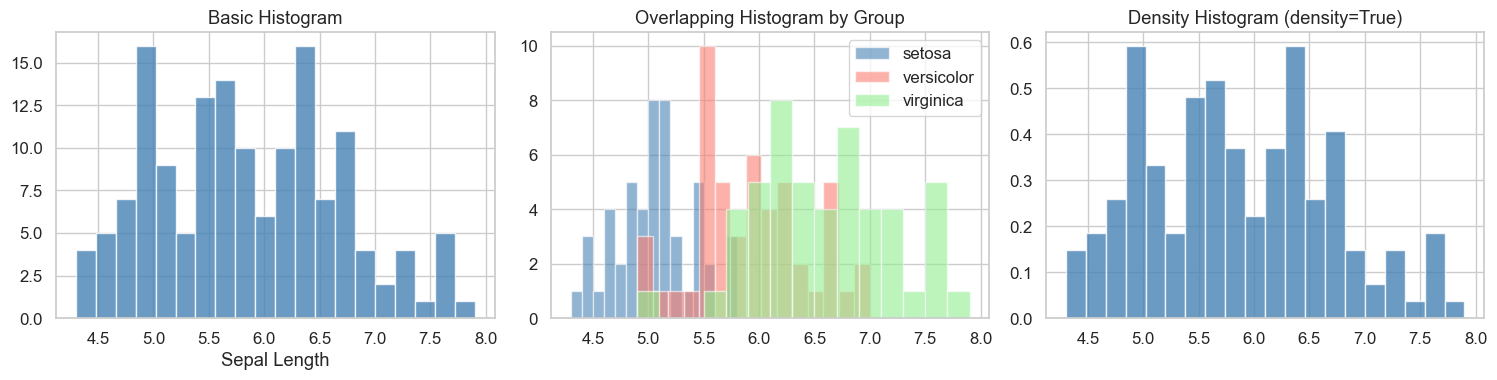

In [2]:
# ======================================================
# 1.1 Histogram
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Basic
axes[0].hist(iris['sepal_length'], bins=20,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Basic Histogram')
axes[0].set_xlabel('Sepal Length')

# Overlapping by group
for species, color in zip(iris['species'].unique(), ['steelblue','salmon','lightgreen']):
    data = iris[iris['species']==species]['sepal_length']
    axes[1].hist(data, bins=15, alpha=0.6, label=species, color=color)
axes[1].legend()
axes[1].set_title('Overlapping Histogram by Group')

# Density (normalize)
axes[2].hist(iris['sepal_length'], bins=20, density=True,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title('Density Histogram (density=True)')

plt.tight_layout()
plt.show()

# PARAMETERS hist:
# bins=20           → จำนวน bins (หรือ 'auto','fd','sturges')
# density=True      → normalize เป็น probability density
# cumulative=True   → cumulative histogram
# alpha=0.7         → ความโปร่งใส
# color='steelblue' → สี
# edgecolor='black' → สีขอบ
# label='name'      → ชื่อสำหรับ legend
# orientation='horizontal' → แนวนอน

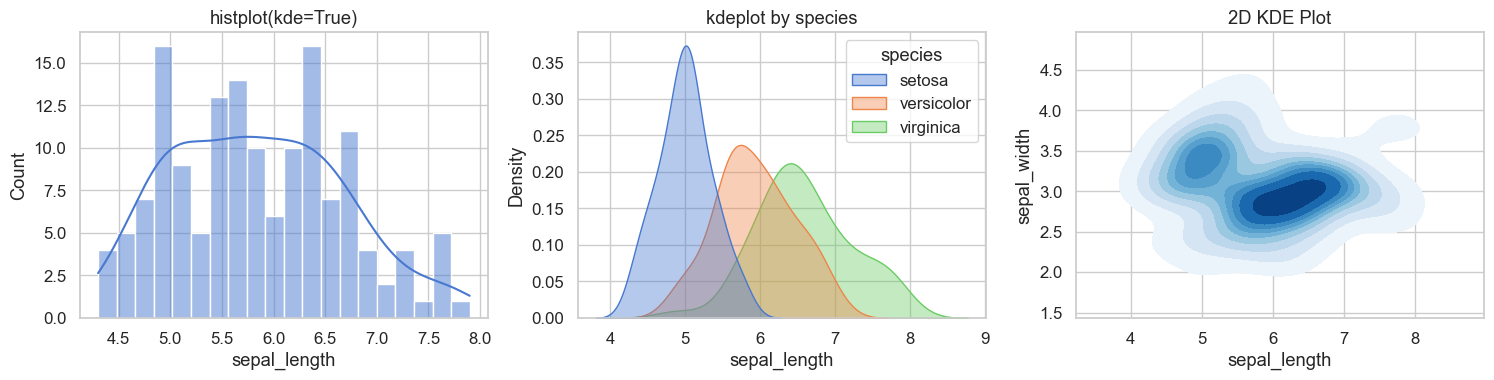

In [3]:
# ======================================================
# 1.2 KDE (Kernel Density Estimate) + histplot
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# sns.histplot – histogram + KDE
sns.histplot(iris['sepal_length'], kde=True, bins=20, ax=axes[0])
axes[0].set_title('histplot(kde=True)')

# sns.kdeplot – KDE only
sns.kdeplot(data=iris, x='sepal_length', hue='species',
            fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('kdeplot by species')

# 2D KDE
sns.kdeplot(data=iris, x='sepal_length', y='sepal_width',
            fill=True, cmap='Blues', levels=10, ax=axes[2])
axes[2].set_title('2D KDE Plot')

plt.tight_layout()
plt.show()

# PARAMETERS kdeplot:
# hue='col'         → แบ่งสีตาม column
# fill=True         → เติมสีใต้เส้น
# bw_adjust=1.0     → ความเรียบ (>1=เรียบขึ้น, <1=ขรุขระ)
# cut=3             → เส้น KDE ยืดไปกี่ std
# levels=10         → จำนวน contour levels (2D)
# cumulative=True   → cumulative KDE

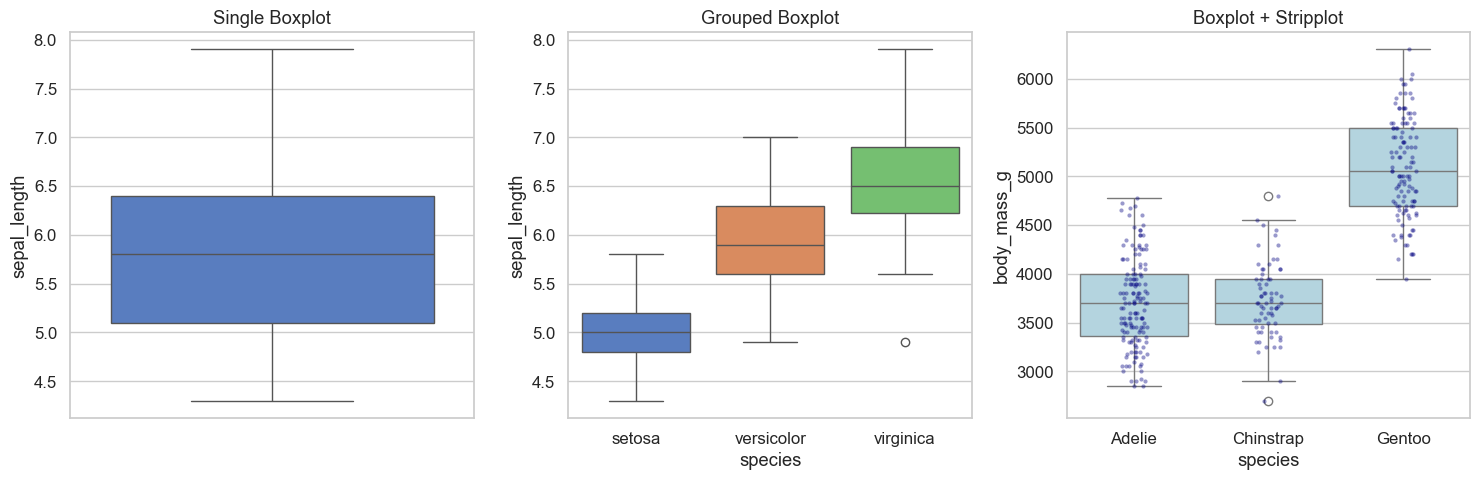

In [4]:
# ======================================================
# 1.3 Boxplot
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Basic boxplot
sns.boxplot(data=iris, y='sepal_length', ax=axes[0])
axes[0].set_title('Single Boxplot')

# Grouped boxplot
sns.boxplot(data=iris, x='species', y='sepal_length',
            hue='species', palette='muted', ax=axes[1])
axes[1].set_title('Grouped Boxplot')

# Boxplot + stripplot overlay
sns.boxplot(data=penguins, x='species', y='body_mass_g',
            color='lightblue', ax=axes[2])
sns.stripplot(data=penguins, x='species', y='body_mass_g',
              color='navy', alpha=0.4, size=3, ax=axes[2])
axes[2].set_title('Boxplot + Stripplot')

plt.tight_layout()
plt.show()

# PARAMETERS boxplot:
# x, y          → column names
# hue='col'     → แบ่งกลุ่มย่อย
# order=[...]   → กำหนดลำดับ x
# palette='...' → ชุดสี
# width=0.8     → ความกว้าง box
# fliersize=5   → ขนาด outlier dot
# notch=True    → แสดง notch (confidence interval ของ median)
# showmeans=True→ แสดงจุด mean

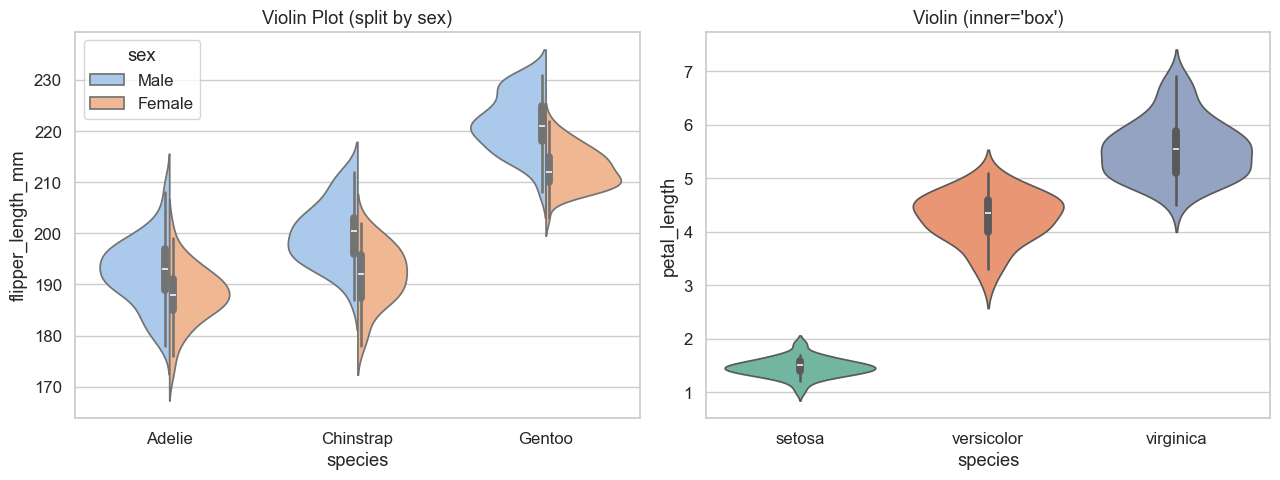

In [5]:
# ======================================================
# 1.4 Violin Plot
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin basic
sns.violinplot(data=penguins, x='species', y='flipper_length_mm',
               hue='sex', split=True,   # split=True → แยกซ้าย/ขวาตาม hue
               palette='pastel', ax=axes[0])
axes[0].set_title('Violin Plot (split by sex)')

# Violin + inner boxplot
sns.violinplot(data=iris, x='species', y='petal_length',
               inner='box',    # 'box','quart','point','stick',None
               palette='Set2', ax=axes[1])
axes[1].set_title("Violin (inner='box')")

plt.tight_layout()
plt.show()

# PARAMETERS violinplot:
# split=True    → (เมื่อมี hue) แบ่งซ้าย/ขวา
# inner='box'   → แสดงอะไรข้างใน: 'box','quart','point','stick',None
# bw_adjust=1   → ความเรียบของ KDE
# scale='width' → 'width' (ทุก violin กว้างเท่ากัน), 'count' (กว้างตาม n), 'area'

---
# 2. Relationship Plots – ความสัมพันธ์

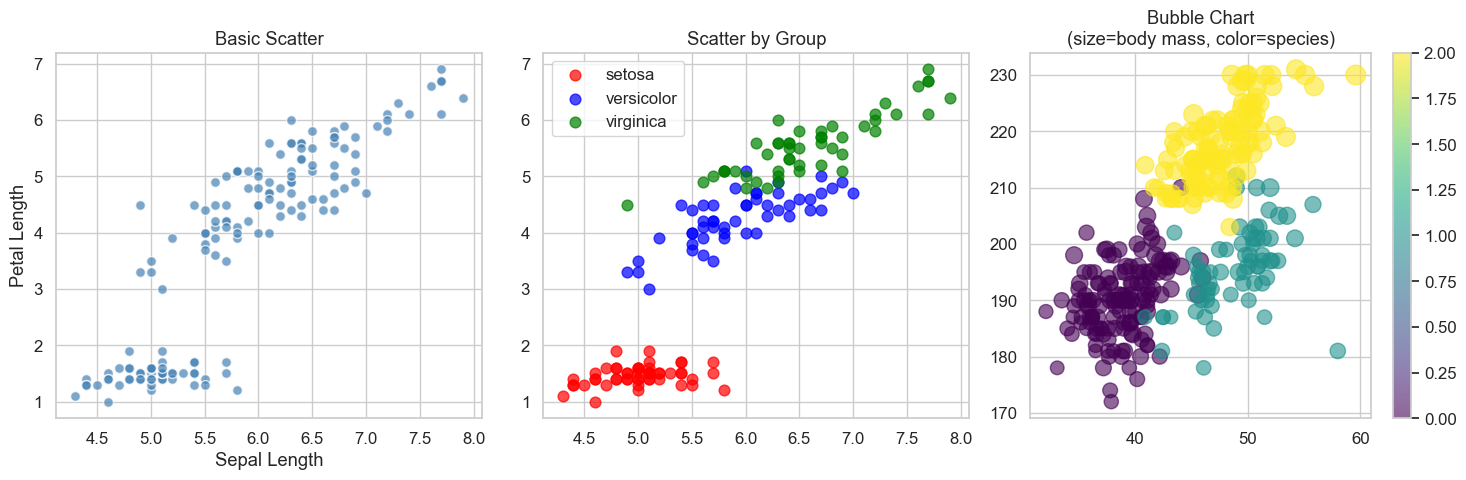

In [6]:
# ======================================================
# 2.1 Scatter Plot
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Basic scatter
axes[0].scatter(iris['sepal_length'], iris['petal_length'],
                alpha=0.7, c='steelblue', edgecolors='white', s=50)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')
axes[0].set_title('Basic Scatter')

# Color by category
colors = {'setosa':'red','versicolor':'blue','virginica':'green'}
for species, grp in iris.groupby('species'):
    axes[1].scatter(grp['sepal_length'], grp['petal_length'],
                    label=species, alpha=0.7, s=60, c=colors[species])
axes[1].legend()
axes[1].set_title('Scatter by Group')

# Bubble chart (size = 3rd variable)
sc = axes[2].scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'],
                     s=penguins['body_mass_g']/30,    # ขนาดตาม body mass
                     c=penguins['species'].astype('category').cat.codes,  # สีตาม species
                     alpha=0.6, cmap='viridis')
plt.colorbar(sc, ax=axes[2])
axes[2].set_title('Bubble Chart\n(size=body mass, color=species)')

plt.tight_layout()
plt.show()

# PARAMETERS scatter:
# s=50              → ขนาด marker
# c='red' / array  → สี (ถ้าเป็น array ต้องใส่ cmap)
# cmap='viridis'    → colormap
# alpha=0.7         → ความโปร่งใส
# marker='o'        → รูปร่าง ('o','s','D','^','*',etc.)
# edgecolors='k'    → สีขอบ

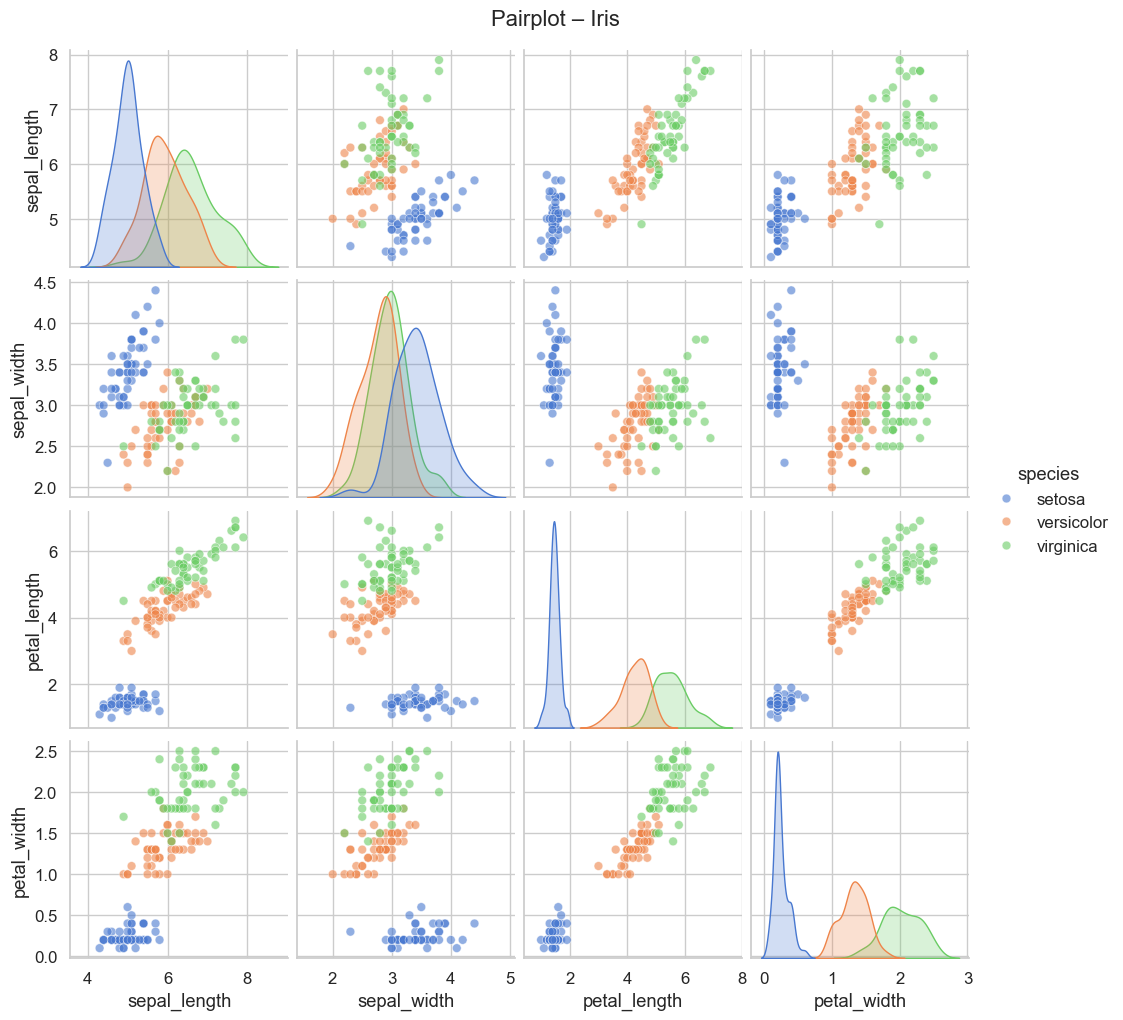

In [7]:
# ======================================================
# 2.2 Pair Plot
# ======================================================

g = sns.pairplot(
    iris,
    hue='species',          # สีตาม column นี้
    diag_kind='kde',        # diagonal: 'hist' หรือ 'kde'
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kws={'fill': True},
    corner=False,           # True = แสดงครึ่งล่าง
)
g.fig.suptitle('Pairplot – Iris', y=1.02)
plt.show()

# PARAMETERS pairplot:
# vars=[...]           → เลือก columns ที่จะแสดง
# hue='col'           → แบ่งสี
# kind='scatter'      → off-diag type: 'scatter','kde','hist','reg'
# diag_kind='kde'     → diagonal type: 'kde','hist'
# corner=True         → ครึ่งล่าง (ประหยัดพื้นที่)
# palette='Set2'      → ชุดสี
# plot_kws={}         → kwargs สำหรับ off-diagonal
# diag_kws={}         → kwargs สำหรับ diagonal

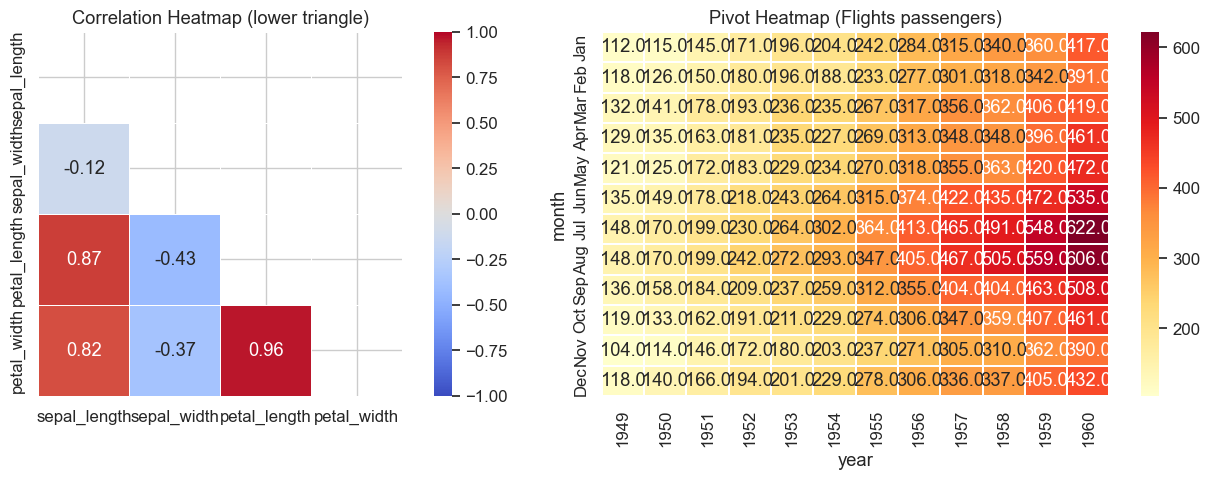

In [8]:
# ======================================================
# 2.3 Heatmap – Correlation & Pivot
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = iris.drop('species', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # ซ่อนครึ่งบน

sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',   # ใส่ตัวเลข, format
    cmap='coolwarm',         # diverging colormap
    center=0,                # center colormap ที่ 0
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Correlation Heatmap (lower triangle)')

# Pivot heatmap (flights dataset)
pv = flights.pivot_table(index='month', columns='year', values='passengers')
sns.heatmap(pv, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.3, ax=axes[1])
axes[1].set_title('Pivot Heatmap (Flights passengers)')

plt.tight_layout()
plt.show()

# PARAMETERS heatmap:
# annot=True         → แสดงตัวเลขในกล่อง
# fmt='.2f'          → format ตัวเลข (.2f, 'd', '.1%')
# cmap='viridis'     → colormap
# center=0           → center ของ colormap
# vmin, vmax         → ช่วง color
# mask=array         → True = ซ่อน cell นั้น
# linewidths=0.5     → ความหนาของเส้นแบ่ง
# square=True        → บังคับให้ cell เป็นสี่เหลี่ยมจัตุรัส
# cbar=False         → ซ่อน color bar

---
# 3. Categorical Plots

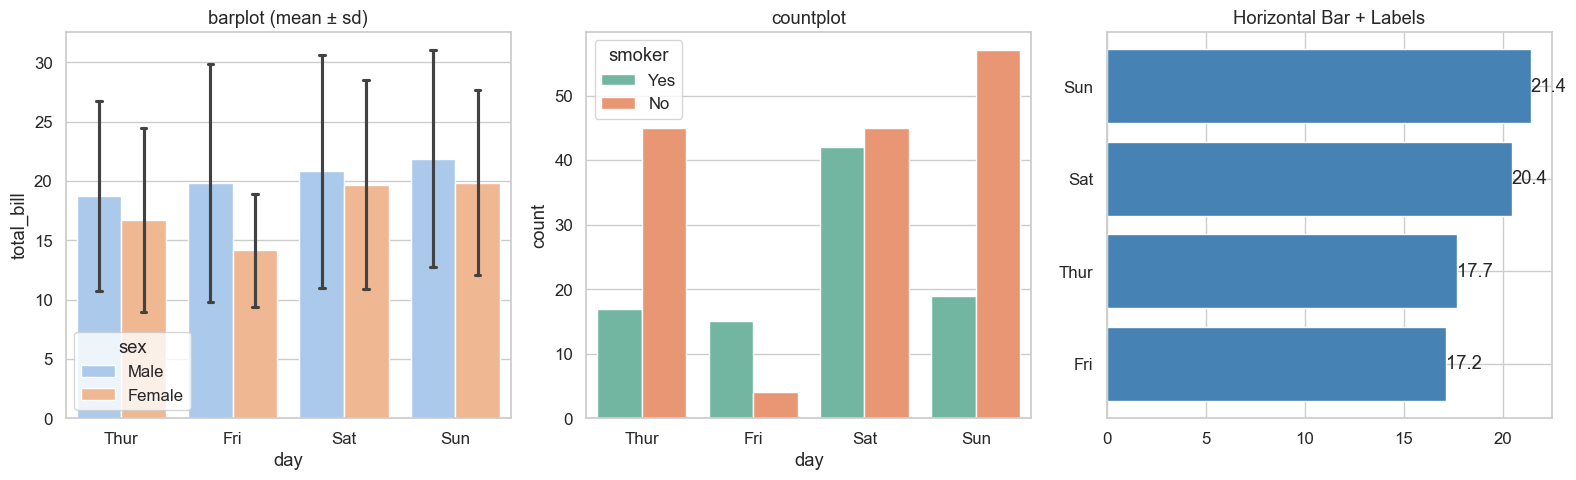

In [9]:
# ======================================================
# 3.1 Bar Chart
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# barplot – ค่าเฉลี่ย + error bar
sns.barplot(data=tips, x='day', y='total_bill',
            hue='sex',
            errorbar='sd',          # error bar: 'sd','se','ci',None
            capsize=0.1,
            palette='pastel',
            ax=axes[0])
axes[0].set_title("barplot (mean ± sd)")

# countplot – นับจำนวน
sns.countplot(data=tips, x='day', hue='smoker',
              palette='Set2', order=['Thur','Fri','Sat','Sun'],
              ax=axes[1])
axes[1].set_title('countplot')

# Horizontal bar
tips_agg = tips.groupby('day')['total_bill'].mean().sort_values()
axes[2].barh(tips_agg.index, tips_agg.values, color='steelblue')
axes[2].bar_label(axes[2].containers[0], fmt='%.1f')  # เพิ่มตัวเลขบน bar
axes[2].set_title('Horizontal Bar + Labels')

plt.tight_layout()
plt.show()

# PARAMETERS barplot:
# estimator='mean'  → ค่าที่ใช้: 'mean','median','sum',np.std
# errorbar='ci'     → 'ci'=95%CI, 'sd'=std, 'se'=std error, ('ci',95)
# order=[...]       → กำหนดลำดับ
# hue_order=[...]   → กำหนดลำดับ hue
# dodge=True        → แยก bar ตาม hue (default=True)
# width=0.8         → ความกว้าง bar

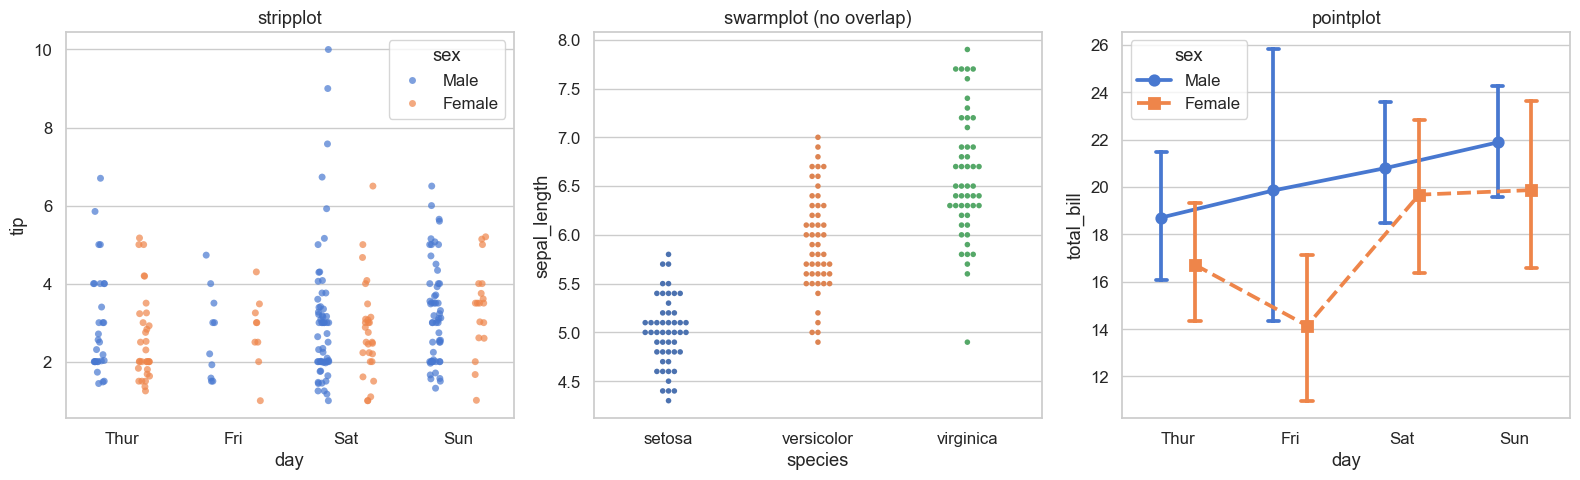

In [10]:
# ======================================================
# 3.2 Strip / Swarm / Point Plot
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# stripplot – กระจาย raw points
sns.stripplot(data=tips, x='day', y='tip',
              hue='sex', dodge=True,  # dodge=True แยกตาม hue
              jitter=True,            # สุ่มเลื่อนตำแหน่งป้องกันทับ
              alpha=0.7, size=5,
              ax=axes[0])
axes[0].set_title('stripplot')

# swarmplot – ไม่ overlap กัน (แต่ช้ากับข้อมูลเยอะ)
sns.swarmplot(data=iris, x='species', y='sepal_length',
              hue='species', palette='deep', size=4, ax=axes[1])
axes[1].set_title('swarmplot (no overlap)')

# pointplot – เส้นเชื่อม mean
sns.pointplot(data=tips, x='day', y='total_bill',
              hue='sex', dodge=0.3,
              markers=['o','s'], linestyles=['-','--'],
              errorbar='ci', capsize=0.1,
              ax=axes[2])
axes[2].set_title('pointplot')

plt.tight_layout()
plt.show()

# PARAMETERS stripplot:
# jitter=True       → สุ่มตำแหน่ง (0-0.5 ระบุปริมาณ)
# dodge=True        → แยกตาม hue
# size=5            → ขนาดจุด
# alpha=0.7         → ความโปร่งใส
# marker='o'        → รูปจุด

---
# 4. Composition Plots

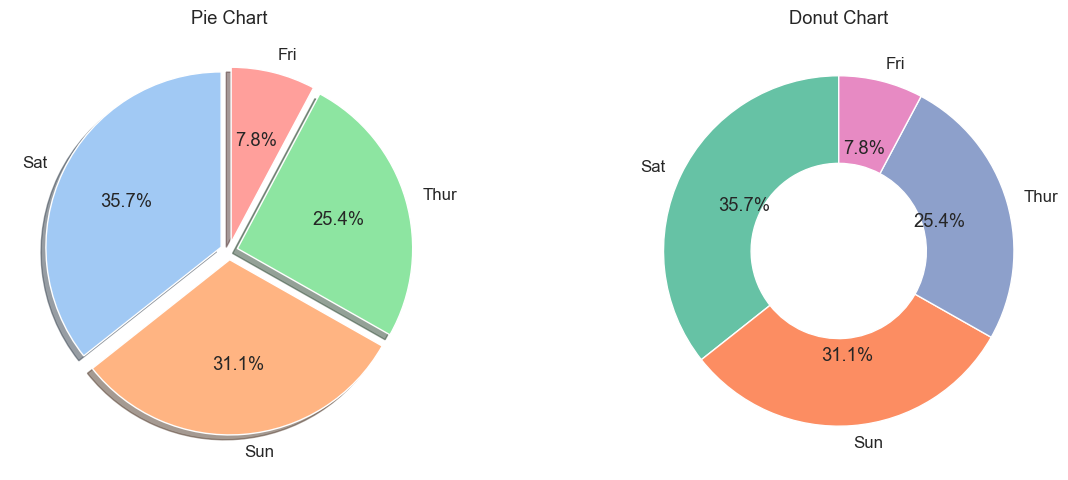

In [11]:
# ======================================================
# 4.1 Pie Chart
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Basic Pie
day_counts = tips['day'].value_counts()
axes[0].pie(
    day_counts.values,
    labels=day_counts.index,
    autopct='%1.1f%%',        # แสดง %
    startangle=90,            # เริ่มจากมุม 90°
    explode=[0.05]*4,         # ระยะห่างจากจุดกลาง
    colors=sns.color_palette('pastel'),
    shadow=True,
)
axes[0].set_title('Pie Chart')

# Donut chart
axes[1].pie(
    day_counts.values,
    labels=day_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2'),
    wedgeprops={'width': 0.5},  # กำหนดให้เป็น donut
)
axes[1].set_title('Donut Chart')

plt.tight_layout()
plt.show()

# PARAMETERS pie:
# autopct='%1.1f%%' → format ตัวเลข %
# startangle=90     → มุมเริ่ม (0=ขวา, 90=บน)
# explode=[...]     → ดึง slice ออก
# shadow=True       → เงา
# wedgeprops={}     → ปรับ wedge: {'width':0.5} = donut
# pctdistance=0.8   → ระยะ % ออกจากกลาง
# labeldistance=1.1 → ระยะ label ออกจากกลาง

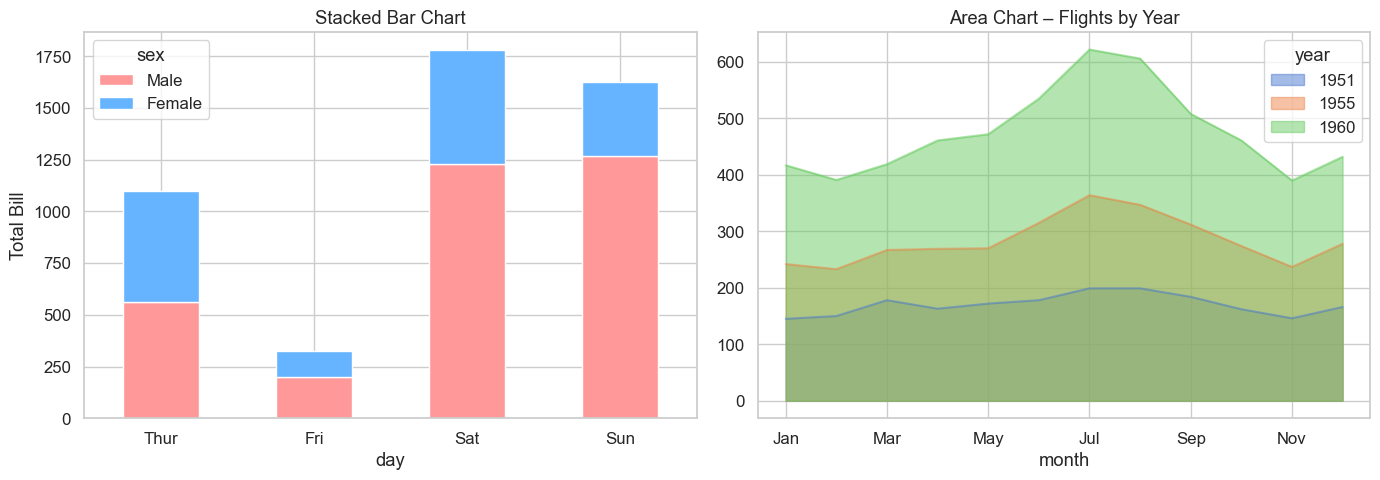

In [12]:
# ======================================================
# 4.2 Stacked Bar + Area Chart
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked Bar
pivot = tips.groupby(['day','sex'])['total_bill'].sum().unstack()
pivot.plot(
    kind='bar',
    stacked=True,
    color=['#ff9999','#66b3ff'],
    ax=axes[0],
    rot=0
)
axes[0].set_title('Stacked Bar Chart')
axes[0].set_ylabel('Total Bill')

# Area Chart
monthly_flights = flights.pivot_table(index='month', columns='year', values='passengers')
monthly_flights[[1951,1955,1960]].plot(
    kind='area',
    stacked=False,
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title('Area Chart – Flights by Year')

plt.tight_layout()
plt.show()

# PARAMETERS plot(kind='bar'):
# stacked=True/False → stack หรือ side-by-side
# rot=0             → หมุน x labels
# width=0.8         → ความกว้าง bar
# color=[...]       → สี

---
# 5. Advanced Plots

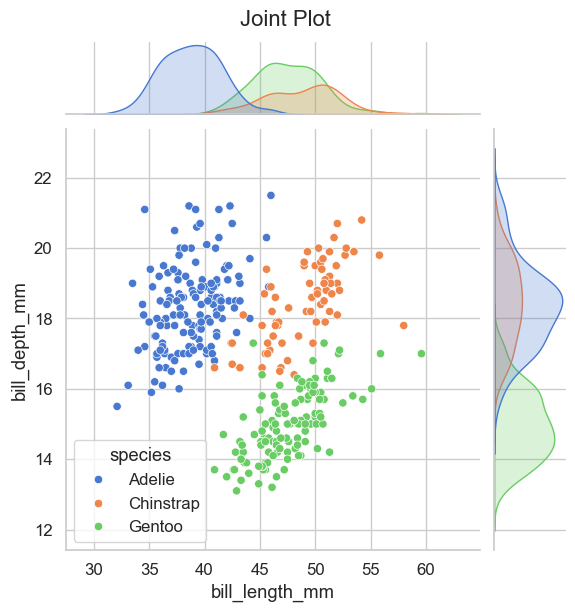

In [13]:
# ======================================================
# 5.1 Joint Plot – distribution + relationship
# ======================================================

g = sns.jointplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    kind='scatter',     # 'scatter','kde','hist','hex','reg','resid'
    height=6,
    ratio=5,            # อัตราส่วน main:marginal
)
g.fig.suptitle('Joint Plot', y=1.02)
plt.show()

# PARAMETERS jointplot:
# kind='scatter'  → 'scatter','kde','hist','hex','reg','resid'
# height=6        → ขนาด
# ratio=5         → main plot vs marginal
# hue='col'       → สีตาม category
# xlim, ylim      → กำหนดขอบเขต

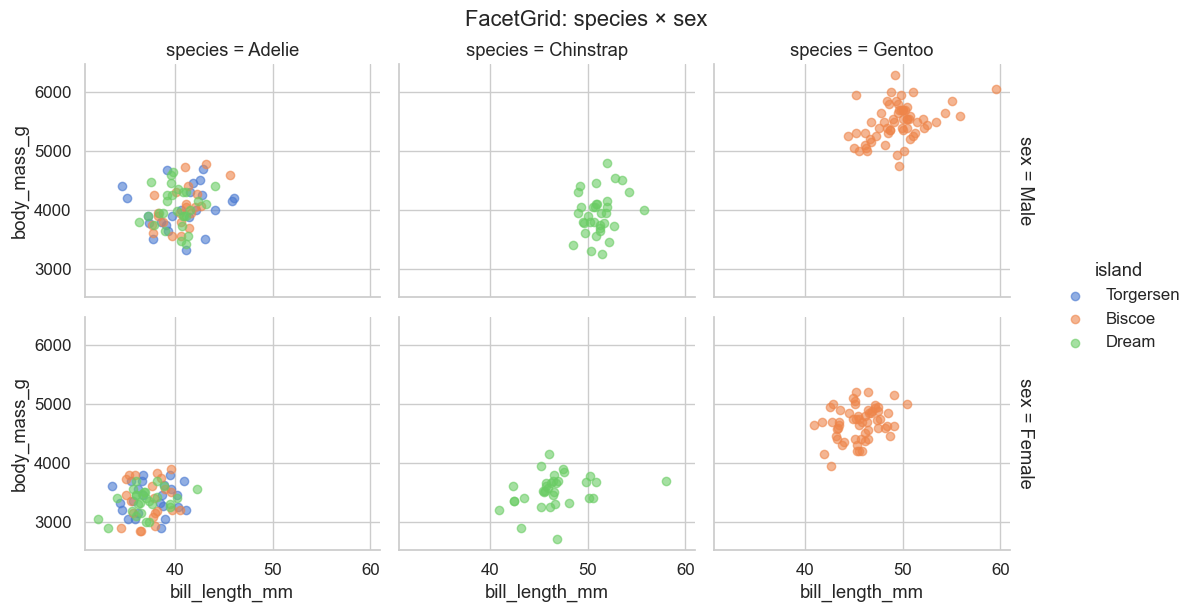

In [14]:
# ======================================================
# 5.2 FacetGrid – หลาย subplots ตาม category
# ======================================================

g = sns.FacetGrid(
    penguins,
    col='species',      # แบ่งตาม column
    row='sex',          # แบ่งตาม row
    hue='island',
    height=3,
    aspect=1.2,
    margin_titles=True,
)
g.map(plt.scatter, 'bill_length_mm', 'body_mass_g', alpha=0.6)
g.add_legend()
g.fig.suptitle('FacetGrid: species × sex', y=1.02)
plt.show()

# PARAMETERS FacetGrid:
# col='col_name'    → แบ่ง columns
# row='row_name'    → แบ่ง rows
# hue='col'         → สีต่างกัน
# col_wrap=3        → จำนวน columns ก่อน wrap (ใช้แทน row)
# height=3          → ความสูงต่อ subplot
# aspect=1.0        → aspect ratio
# sharex, sharey    → share axis

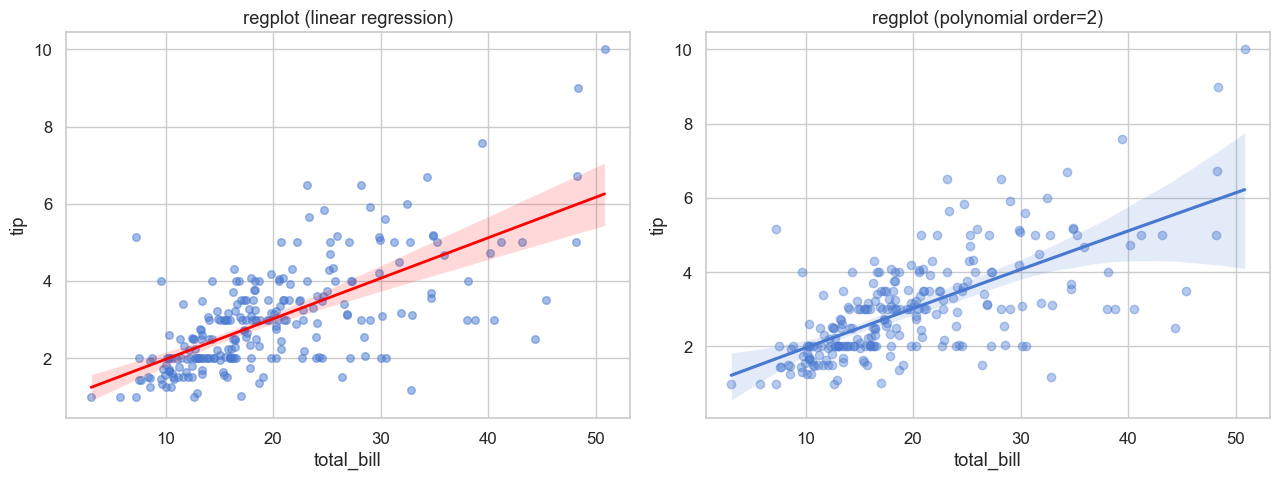

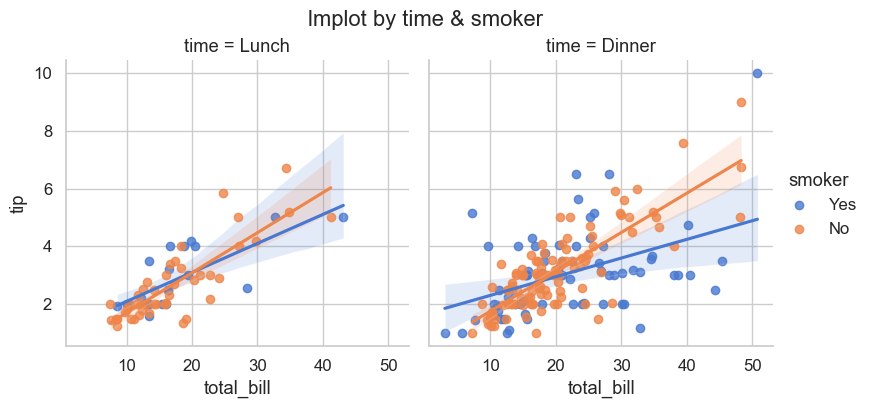

In [15]:
# ======================================================
# 5.3 Regression Plot (lmplot / regplot)
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# regplot – scatter + regression line
sns.regplot(
    data=tips, x='total_bill', y='tip',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'red', 'lw': 2},
    ci=95,          # confidence interval shading
    order=1,        # degree ของ polynomial (1=linear)
    ax=axes[0]
)
axes[0].set_title('regplot (linear regression)')

# Polynomial regression
sns.regplot(
    data=tips, x='total_bill', y='tip',
    order=2,        # quadratic
    scatter_kws={'alpha': 0.4},
    ax=axes[1]
)
axes[1].set_title('regplot (polynomial order=2)')

plt.tight_layout()
plt.show()

# lmplot = regplot แต่ support hue/col/row
g = sns.lmplot(
    data=tips, x='total_bill', y='tip',
    hue='smoker', col='time',
    height=4, ci=95,
)
g.fig.suptitle('lmplot by time & smoker', y=1.02)
plt.show()

# PARAMETERS regplot:
# order=1           → polynomial degree
# ci=95             → confidence interval % (None = ปิด)
# logistic=True     → logistic regression
# lowess=True       → LOWESS smoother (non-parametric)
# robust=True       → robust regression (ลด outlier effect)
# scatter=False     → ซ่อน scatter, แสดงแค่เส้น

---
# 6. Time Series Plots

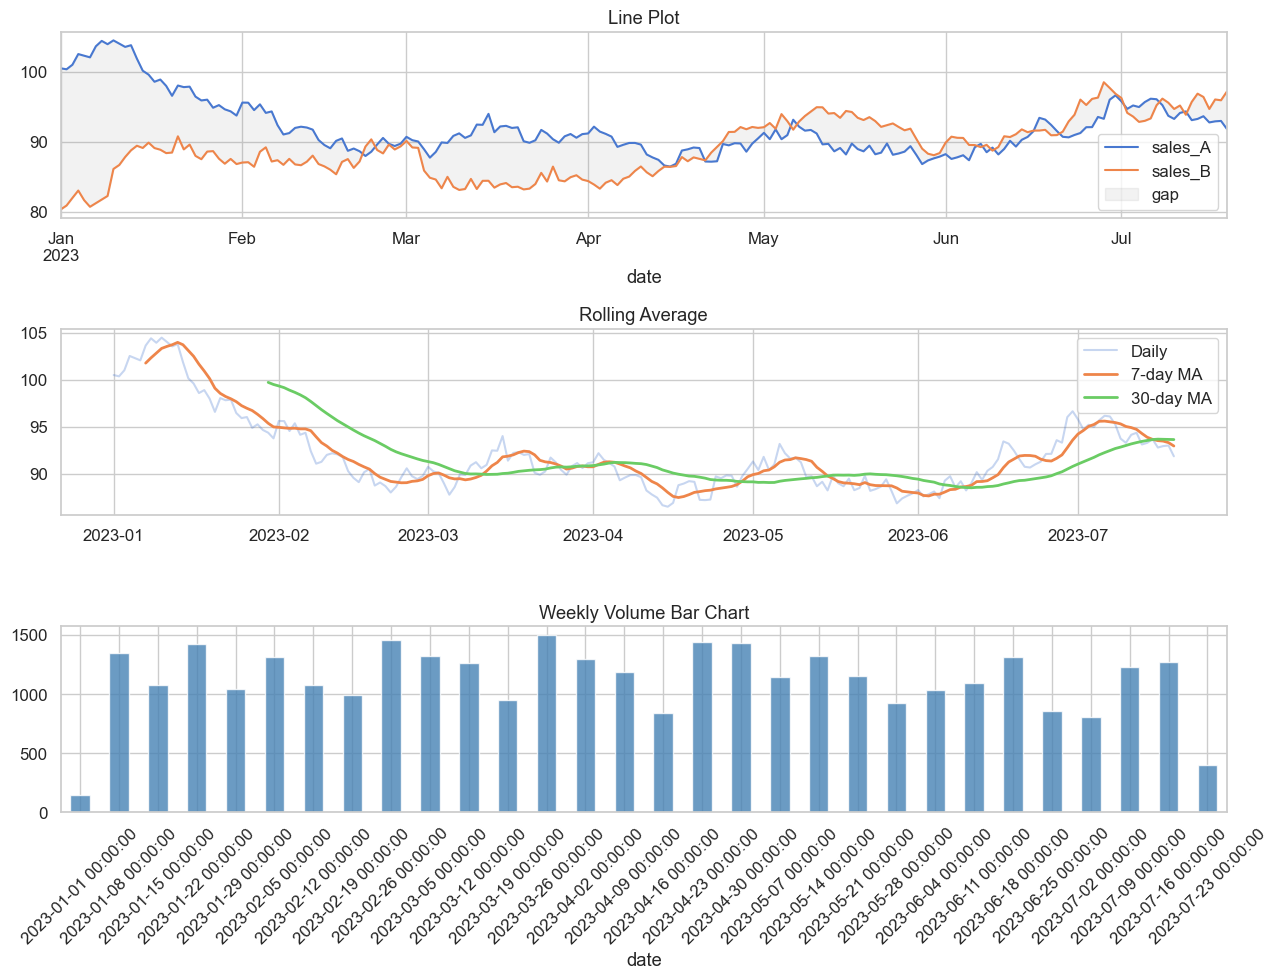

In [16]:
# ======================================================
# 6. Time Series
# ======================================================

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Line plot
ts[['sales_A','sales_B']].plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Line Plot')
axes[0].fill_between(ts.index, ts['sales_A'], ts['sales_B'],
                      alpha=0.1, color='gray', label='gap')
axes[0].legend()

# Rolling Average
roll7  = ts['sales_A'].rolling(window=7).mean()
roll30 = ts['sales_A'].rolling(window=30).mean()
axes[1].plot(ts.index, ts['sales_A'], alpha=0.3, label='Daily')
axes[1].plot(roll7.index,  roll7,  label='7-day MA',  lw=2)
axes[1].plot(roll30.index, roll30, label='30-day MA', lw=2)
axes[1].legend()
axes[1].set_title('Rolling Average')

# Bar chart for volume
ts['volume'].resample('W').sum().plot(kind='bar', ax=axes[2], color='steelblue', alpha=0.8)
axes[2].set_title('Weekly Volume Bar Chart')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# PARAMETERS rolling:
# window=7          → ขนาด window (จำนวน periods)
# min_periods=1     → ขั้นต่ำ periods ก่อนคำนวณ (ไม่ให้ NaN)
# center=False      → ให้ window อยู่ขวา (trailing) หรือตรงกลาง
# .mean(),.sum(),.std(),.min(),.max(),.apply(func)

---
# 7. 3D Plots

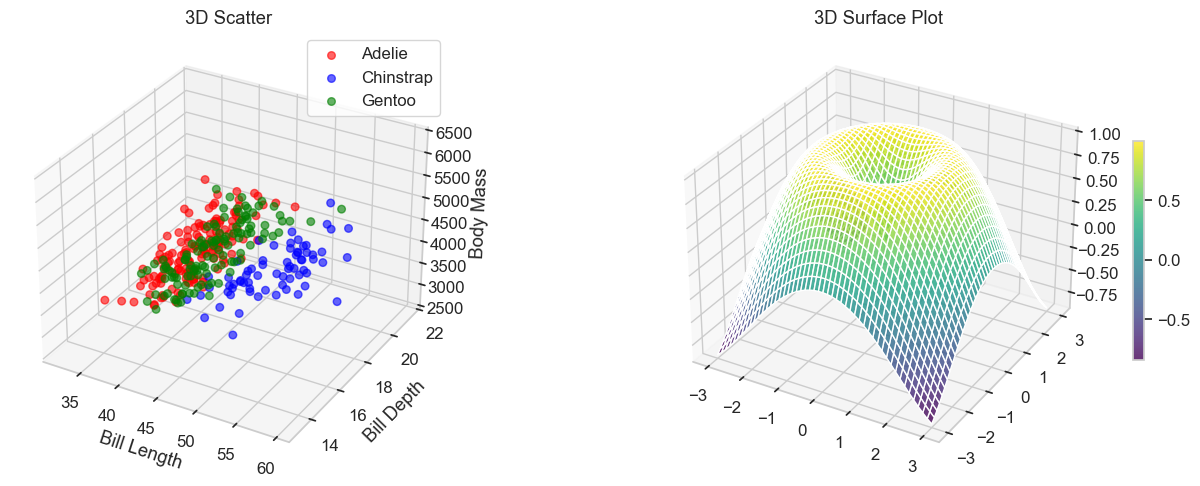

In [17]:
# ======================================================
# 7. 3D Scatter + Surface
# ======================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 5))

# 3D Scatter
ax1 = fig.add_subplot(121, projection='3d')
colors_3d = {'Adelie':'red','Chinstrap':'blue','Gentoo':'green'}
for species, grp in penguins.groupby('species'):
    ax1.scatter(
        grp['bill_length_mm'],
        grp['bill_depth_mm'],
        grp['body_mass_g'],
        label=species, alpha=0.6, s=30,
        c=colors_3d[species]
    )
ax1.set_xlabel('Bill Length'); ax1.set_ylabel('Bill Depth'); ax1.set_zlabel('Body Mass')
ax1.set_title('3D Scatter')
ax1.legend()

# 3D Surface
ax2 = fig.add_subplot(122, projection='3d')
x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
fig.colorbar(surf, ax=ax2, shrink=0.5)
ax2.set_title('3D Surface Plot')

plt.tight_layout()
plt.show()

# PARAMETERS plot_surface:
# cmap='viridis'      → colormap
# alpha=0.8           → ความโปร่งใส
# rstride, cstride=1  → ความละเอียด grid
# ax.view_init(30, 45) → มุมมอง (elevation, azimuth)

---
# 8. Interactive Plots ด้วย Plotly

In [18]:
# pip install plotly
import plotly.express as px
import plotly.graph_objects as go

# ======================================================
# 8.1 Scatter Interactive
# ======================================================

fig = px.scatter(
    penguins,
    x='bill_length_mm',
    y='body_mass_g',
    color='species',       # สีตาม column
    symbol='sex',          # รูปตาม column
    size='flipper_length_mm',  # ขนาดตาม column
    hover_data=['island'],     # ข้อมูลเพิ่มเมื่อ hover
    title='Penguin: Bill Length vs Body Mass',
    trendline='ols',       # เส้น regression ('ols','lowess')
)
fig.show()

# PARAMETERS px.scatter:
# color='col'          → สีตาม column
# size='col'           → ขนาดตาม column (bubble)
# symbol='col'         → รูปร่างตาม column
# facet_col='col'      → แบ่ง columns
# facet_row='col'      → แบ่ง rows
# hover_data=[...]     → ข้อมูลเพิ่มเติมเมื่อ hover
# animation_frame='col'→ animation slider
# trendline='ols'      → เส้น trend

In [19]:
# ======================================================
# 8.2 Plotly – Bar, Box, Histogram
# ======================================================

# Interactive Bar
fig_bar = px.bar(
    tips.groupby(['day','sex'])['total_bill'].mean().reset_index(),
    x='day', y='total_bill', color='sex',
    barmode='group',   # 'group' หรือ 'stack'
    title='Avg Bill by Day & Sex',
    text_auto='.1f',   # แสดงตัวเลขบน bar
)
fig_bar.show()

# Interactive Box
fig_box = px.box(
    penguins, x='species', y='body_mass_g',
    color='sex', points='outliers',  # 'all','outliers','suspectedoutliers',False
    notched=True,
    title='Body Mass by Species & Sex'
)
fig_box.show()

# Interactive Histogram
fig_hist = px.histogram(
    iris, x='sepal_length', color='species',
    nbins=20, barmode='overlay',
    marginal='box',  # 'box','violin','rug' – เพิ่ม marginal plot
    title='Sepal Length Distribution'
)
fig_hist.show()

In [20]:
# ======================================================
# 8.3 Plotly Heatmap + Line (Time Series)
# ======================================================

# Interactive Heatmap
pv = flights.pivot_table(index='month', columns='year', values='passengers')
fig_heat = px.imshow(
    pv,
    color_continuous_scale='YlOrRd',
    text_auto=True,
    aspect='auto',
    title='Flights Passengers Heatmap'
)
fig_heat.show()

# Interactive Line (Time Series)
fig_ts = px.line(
    ts.reset_index(), x='date',
    y=['sales_A', 'sales_B'],
    title='Sales Time Series',
)
fig_ts.add_hline(y=ts['sales_A'].mean(), line_dash='dash',
                  annotation_text='Avg A')
fig_ts.show()

# PARAMETERS px.line:
# line_dash='col'     → รูปแบบเส้นตาม column
# markers=True        → แสดง marker จุด
# facet_col='col'     → แบ่งหน้าต่าง
# range_x=[start,end] → กำหนดช่วง x

---
# 9. Subplots & Layout

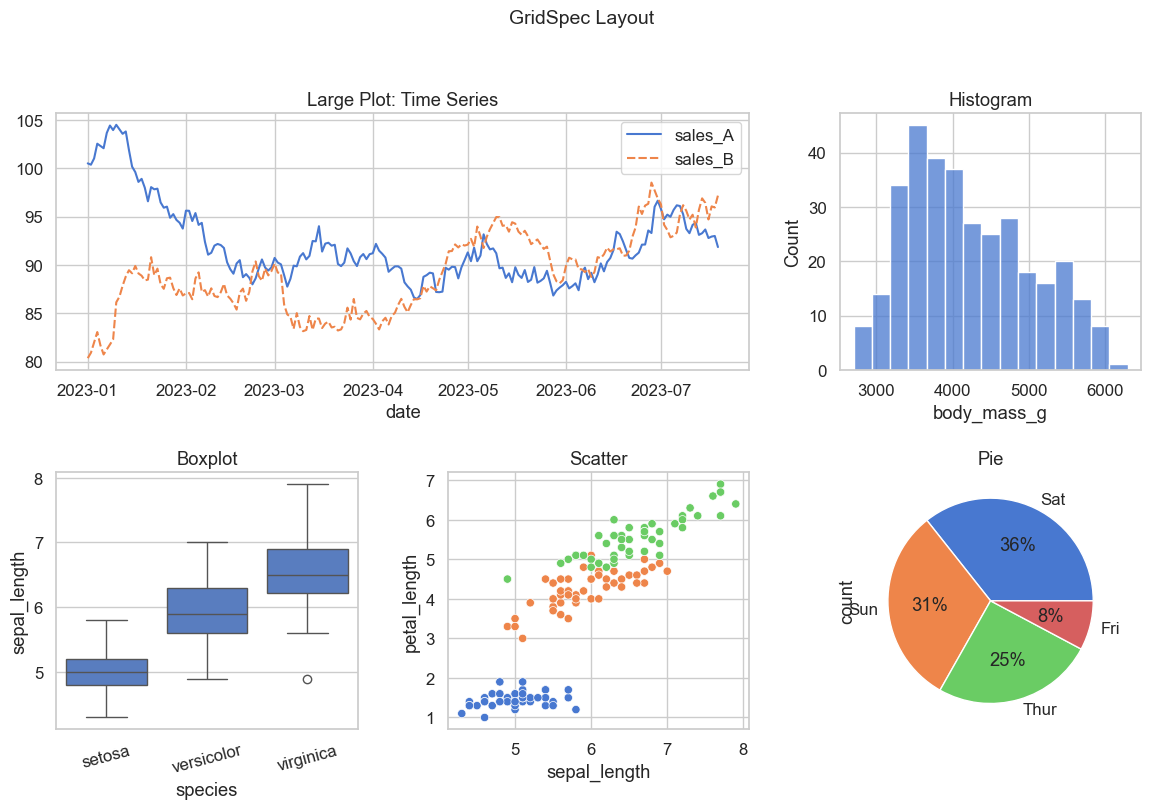

In [21]:
# ======================================================
# 9.1 GridSpec – subplots ขนาดต่างกัน
# ======================================================

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.4, wspace=0.3)

# Plot ใหญ่ข้ามสอง columns
ax1 = fig.add_subplot(gs[0, :2])  # row 0, col 0-1
sns.lineplot(data=ts[['sales_A','sales_B']], ax=ax1)
ax1.set_title('Large Plot: Time Series')

# Plot ขวาบน
ax2 = fig.add_subplot(gs[0, 2])   # row 0, col 2
sns.histplot(penguins['body_mass_g'], ax=ax2, bins=15)
ax2.set_title('Histogram')

# สามช่องล่าง
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=iris, x='species', y='sepal_length', ax=ax3)
ax3.set_title('Boxplot')
ax3.tick_params(axis='x', rotation=15)

ax4 = fig.add_subplot(gs[1, 1])
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',
                hue='species', ax=ax4, legend=False)
ax4.set_title('Scatter')

ax5 = fig.add_subplot(gs[1, 2])
tips['day'].value_counts().plot.pie(ax=ax5, autopct='%1.0f%%')
ax5.set_title('Pie')

fig.suptitle('GridSpec Layout', fontsize=14, y=1.01)
plt.show()

# PARAMETERS GridSpec:
# nrows, ncols         → จำนวน rows, columns
# hspace=0.4           → ช่องว่าง vertical
# wspace=0.3           → ช่องว่าง horizontal
# height_ratios=[2,1]  → สัดส่วนความสูง
# width_ratios=[1,2,1] → สัดส่วนความกว้าง

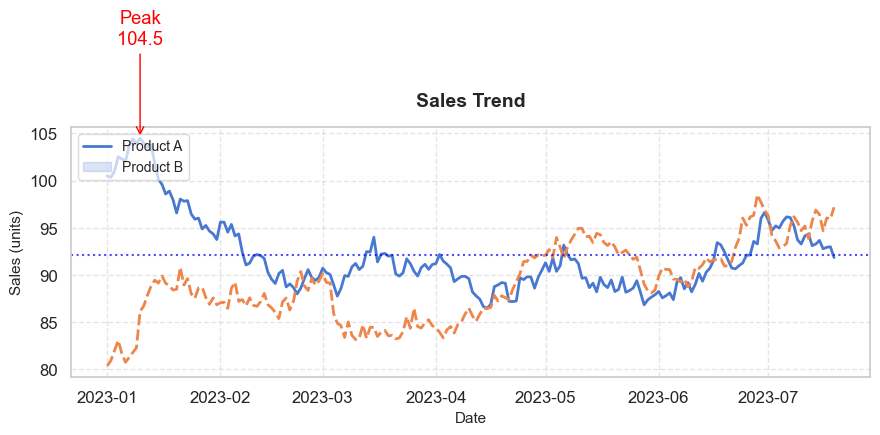

In [22]:
# ======================================================
# 9.2 Style & Customization Tips
# ======================================================

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(data=ts[['sales_A','sales_B']], ax=ax, linewidth=2)

# ---- Title & Labels ----
ax.set_title('Sales Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Sales (units)', fontsize=11)

# ---- Legend ----
ax.legend(labels=['Product A','Product B'],
          loc='upper left',       # 'best','upper right',etc.
          framealpha=0.7,
          fontsize=10)

# ---- Grid ----
ax.grid(True, linestyle='--', alpha=0.5)

# ---- Annotations ----
max_idx = ts['sales_A'].idxmax()
ax.annotate(
    f'Peak\n{ts["sales_A"].max():.1f}',
    xy=(max_idx, ts['sales_A'].max()),
    xytext=(max_idx, ts['sales_A'].max() + 10),
    arrowprops=dict(arrowstyle='->', color='red'),
    ha='center', color='red'
)

# ---- Horizontal / Vertical lines ----
ax.axhline(ts['sales_A'].mean(), color='blue', linestyle=':', alpha=0.7,
           label=f'Avg A: {ts["sales_A"].mean():.1f}')

# ---- Tight layout ----
plt.tight_layout()
plt.show()

---
# สรุปตาราง: เลือก Plot อย่างไร?

## ตามวัตถุประสงค์
| ต้องการดู | Plot แนะนำ | Library |
|----------|-----------|---------|
| การกระจายของตัวแปรเดียว | histogram, kde, boxplot | plt / sns |
| เปรียบการกระจายหลายกลุ่ม | violin, boxplot, ridgeplot | sns |
| ความสัมพันธ์ 2 ตัวแปร | scatter, regplot | plt / sns |
| ความสัมพันธ์ทุก pairs | pairplot | sns |
| Correlation matrix | heatmap | sns |
| เปรียบ category | barplot, pointplot | sns |
| Raw data points | stripplot, swarmplot | sns |
| สัดส่วน | pie, donut, stacked bar | plt |
| เปลี่ยนแปลงตามเวลา | line, area, rolling | plt |
| หลาย subgroup | FacetGrid, lmplot | sns |
| 3 ตัวแปรพร้อมกัน | bubble (scatter+size), 3D | plt |
| Interactive | scatter, box, heatmap, line | plotly |

## Seaborn Cheatsheet
```
Distribution:  histplot, kdeplot, ecdfplot, rugplot
Categorical:   barplot, countplot, boxplot, violinplot,
               stripplot, swarmplot, pointplot
Relational:    scatterplot, lineplot
Regression:    regplot, lmplot, residplot
Matrix:        heatmap, clustermap
Multi-plot:    pairplot, jointplot, FacetGrid, PairGrid
```

## Colormap Cheatsheet
| ประเภท | Colormap |
|--------|----------|
| Sequential (เล็ก→ใหญ่) | viridis, plasma, Blues, YlOrRd |
| Diverging (ลบ→0→บวก) | coolwarm, RdBu, BrBG |
| Qualitative (categorical) | Set1, Set2, tab10, Paired |
| Perceptually uniform | viridis, cividis, inferno |